# 🌦️ Majira AI: 7-Day Weather Forecast with LSTM
This notebook uses LSTM to forecast temperature and rainfall for the next 7 days using 30 days of historical data.

In [14]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [15]:

df = pd.read_csv("Nairobi 2023-2025.csv")
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)
df = df.sort_index()
df.head(10)


,tempmax,tempmin,temp,dew,humidity,precip,windspeed,windspeedmax,windspeedmin,winddir,sealevelpressure,cloudcover,visibility
datetime,,,,,,,,,,,,,
2023-01-01,26.0,14.8,20.1,10.6,56.7,0.0,36.2,36.2,0.5,75.5,1022.6,51.6,10.3
2023-01-02,23.0,14.8,18.5,11.8,66.2,0.0,36.5,36.5,1.3,75.5,1022.2,66.4,10.3
2023-01-03,22.1,16.0,18.5,14.0,76.1,0.0,38.3,38.3,1.7,73.0,1022.5,75.1,10.0
2023-01-04,21.1,16.0,17.9,14.2,80.1,0.0,27.7,27.7,1.1,68.3,1022.4,83.6,10.1
2023-01-05,24.0,14.9,18.6,11.3,65.5,0.0,31.7,31.7,1.1,54.1,1022.0,70.8,10.1
2023-01-06,26.1,12.0,20.2,8.6,50.2,0.0,27.5,27.5,0.0,67.7,1022.1,23.5,10.3
2023-01-07,26.1,14.0,20.4,10.0,54.2,0.0,37.6,37.6,0.2,61.4,1021.4,24.6,10.3
2023-01-08,27.0,15.9,20.9,12.2,59.2,0.0,32.8,32.8,0.6,61.2,1020.7,46.6,10.4
2023-01-09,26.1,16.1,20.5,13.4,66.4,0.0,29.5,29.5,1.1,61.9,1021.5,71.1,10.3


In [16]:

data = df[['temp', 'precip']].copy()
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)


In [17]:

def create_7_day_sequences(data, input_window=30, forecast_horizon=7):
    X, y = [], []
    for i in range(len(data) - input_window - forecast_horizon + 1):
        X.append(data[i:i+input_window])
        y.append(data[i+input_window:i+input_window+forecast_horizon])
    return np.array(X), np.array(y)

X, y = create_7_day_sequences(scaled_data)
X.shape, y.shape


((786, 30, 2), (786, 7, 2))

In [18]:

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
X_train.shape, y_train.shape


((628, 30, 2), (628, 7, 2))

In [24]:
from tensorflow.keras import Input

model = Sequential()
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(64, activation='relu', return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(7 * 2))  # 7 days * 2 features
model.compile(optimizer='adam', loss='mse')
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 30, 64)              │          17,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 14)                  │             910 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51,086 (199.55 KB)

 Trainable params: 51,086 (199.55 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:

y_train_flat = y_train.reshape((y_train.shape[0], y_train.shape[1] * y_train.shape[2]))
y_test_flat = y_test.reshape((y_test.shape[0], y_test.shape[1] * y_test.shape[2]))


In [26]:

history = model.fit(X_train, y_train_flat, epochs=50, batch_size=32, validation_split=0.1)


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 0.1341 - val_loss: 0.0312
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0497 - val_loss: 0.0095
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0247 - val_loss: 0.0102
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0216 - val_loss: 0.0101
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0204 - val_loss: 0.0091
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0201 - val_loss: 0.0094
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0181 - val_loss: 0.0081
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0214 - val_loss: 0.0095
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0194 - val_loss: 0.0094
Epoch 10/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0184 - val_loss: 0.0098
Epoch 11/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0183 - val_loss: 0.0095
Epoch 12/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0

In [27]:

predictions = model.predict(X_test)
predictions = predictions.reshape((-1, 7, 2))
predicted_values = scaler.inverse_transform(predictions.reshape(-1, 2))
actual_values = scaler.inverse_transform(y_test.reshape(-1, 2))


4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step WARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002440CACBEC0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step


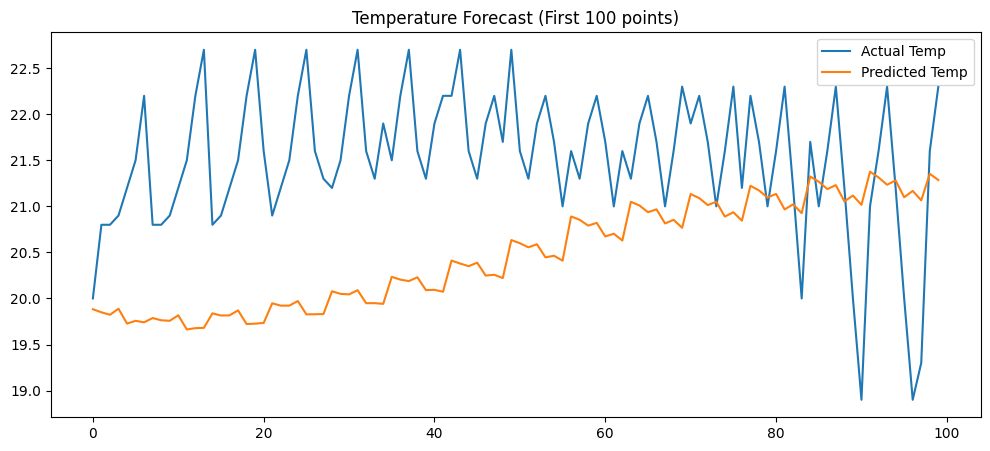

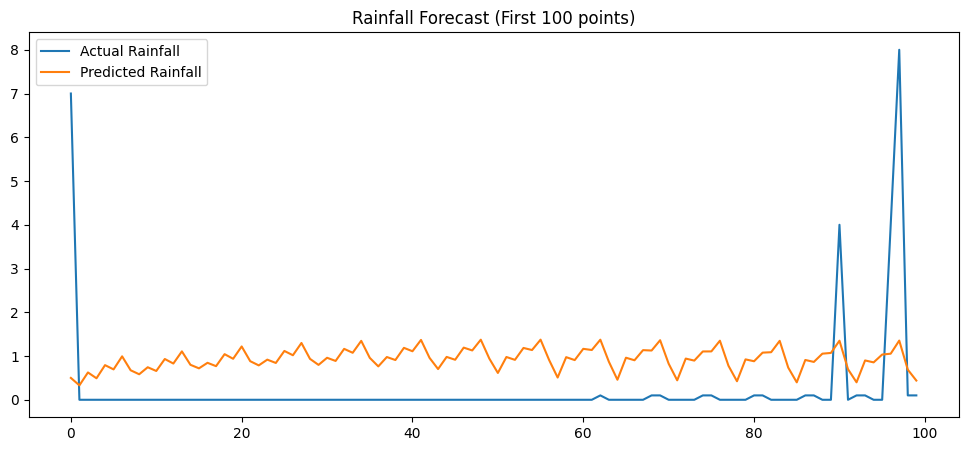

In [28]:

plt.figure(figsize=(12, 5))
plt.plot(actual_values[:100, 0], label='Actual Temp')
plt.plot(predicted_values[:100, 0], label='Predicted Temp')
plt.title("Temperature Forecast (First 100 points)")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(actual_values[:100, 1], label='Actual Rainfall')
plt.plot(predicted_values[:100, 1], label='Predicted Rainfall')
plt.title("Rainfall Forecast (First 100 points)")
plt.legend()
plt.show()